# Pandas Plotting Basics


In [1]:
# %pip install pandas numpy     ### ensure pandas and numpy are installed; uncomment when done
# %pip install matplotlib       ### ensure matplotlib is installed; uncomment when done

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt ### because pandas.plot is still matplotlib
# %matplotlib inline            ### uncomment if using Jupyter Notebook
                                ### unless using Jupyter < 7
                                ### use plt.show() to display plots in other environments  

```{contents}
:local:
:depth: 2
```


<!-- moved-from-landing: 0500-visualization -->

## Visualization Orientation


Dr. Andrew Abela created this chart chooser visualization in 2013. The four-dimension chart categorization offer great insight when choosing visualizations. 

```{figure} ../../figures/andrew-abela-chart-chooser.jpg
:name: andrew-abela-chart-chooser
:width: 90%
:align: center

[Andrew Abela Chart Chooser](https://datavizblog.com/2013/04/29/andrew-abelas-chart-chooser/)
```


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Overview


**Data visualization** is the art and science of transforming raw numbers into compelling visual stories. While spreadsheets and statistical summaries provide precise information, visualizations reveal patterns, relationships, and insights that would remain hidden in tables of data. 

Imagine trying to understand weather patterns from thousands of temperature readings versus seeing them plotted as a line graph over time—the visual immediately shows trends, seasonal cycles, and anomalies that numbers alone cannot convey.

<!-- **The Visualization Landscape**

While this course focuses on Python, it's valuable to understand the broader visualization ecosystem. Different tools serve different purposes:

Python Libraries:

- **Matplotlib**: The foundational library providing complete control and customization
- **Seaborn**: Built on Matplotlib, offering beautiful statistical plots with simpler syntax
- **Plotly**: Creates interactive, web-ready visualizations perfect for dashboards
- **Pandas**: Provides quick, convenient plotting directly from DataFrames for rapid exploration

Business Intelligence Platforms:

- **Tableau**: Drag-and-drop interface for creating professional dashboards and reports
- **Power BI**: Microsoft's business analytics solution with strong Excel integration -->

Each tool has its strengths: Python excels in programmatic control and integration with data analysis workflows, while `R` provides statistical visualization excellence, while Tableau and Power BI offer user-friendly interfaces for business users.


**Why Visualization is Essential**

Data visualization transforms numbers into understanding, serving three fundamental purposes:

- **Exploration and Discovery**: Visualization reveals patterns, outliers, and relationships invisible in raw data, guiding initial analysis and data cleaning decisions.

- **Communication and Persuasion**: Well-crafted visuals convey complex findings to diverse audiences, translating technical results into accessible insights.

- **Decision Support and Action**: Visualization provides clarity for confident decision-making through dashboards, trend analysis, and comparative displays.

Ultimately, visualization bridges the gap between data analysis and actionable insight.    


Effective data visualization follows four key principles:

- Context is Key: Design for your specific audience and their decision-making needs.

- Keep It Simple: Use clear labels and remove unnecessary elements that don't add value.

- Choose the Right Chart Type: Match chart types to data structure: 
  - bars for categories, 
  - lines for trends, 
  - scatter plots for relationships.

- Tell a Story: Structure visualizations to guide the audience through a logical narrative flow.
 


### Common Tools and Libraries

The data visualization landscape offers tools ranging from point-and-click platforms to code-based libraries. Understanding this ecosystem helps you choose the right tool for your needs.

Business Intelligence Platforms:
- **Tableau**: Industry-leading dashboard creation with drag-and-drop interface
- **Power BI**: Microsoft's analytics platform with strong Excel and cloud integration

Python Visualization Libraries:
- **Matplotlib**: The foundational library providing complete control over plot elements
- **Seaborn**: Statistical graphics with simplified syntax, built on Matplotlib. Seaborn is a higher-level library specifically designed for creating more visually appealing and informative statistical graphics with less code. It's excellent for exploring relationships between variables. Seaborn also requires Matplotlib as a dependency. 
- **Plotly**: Interactive, web-ready visualizations including 3D and geographic plots
- **Pandas**: Quick plotting directly from DataFrames for exploratory analysis

Why Focus on Python?

While business tools excel at dashboard creation and user-friendly interfaces, Python libraries offer several advantages for data scientists:
- **Integration**: Seamless workflow from data analysis to visualization
- **Reproducibility**: Code-based plots can be version controlled and automated
- **Customization**: Complete control over every visual element
- **Cost**: Open-source tools reduce licensing expenses

This chapter focuses on **Pandas visualization**—the fastest way to create exploratory plots directly from your data. 


### Which LibraryPlot to Use?

It is essential to know which plots to use when the need for data visualization arises. **Matplotlib** (`plt/ax`), **Pandas** (`df.plot`), and **Seaborn** (`.`) each have a set of functions and methods for data visualization. You will learn about the functions and methods later, but here is a summary of them. Pay attention to what they are used for for now and use this table as a reference.

| Plot Type   | Pandas (`.plot`)    | Matplotlib (`plt`)   | Seaborn (`sns`)| Uses   |
| -------------------- | ---------------- | ---------------------| ------------ | ---------------------- |
| **Line**    | `.line()`/`.plot()`   | `.plot()`   | `.lineplot()`   | Time series, trends    |
| **Scatter**    | `.scatter(x, y)`    | `.scatter()`    | `.scatterplot()`    | Correlations, relationships   |    
| **Bar (vert.)**   | `.bar()`   | `.bar()`    | `.barplot()`   | Category comparisons   |
| **Bar (horiz.)** | `.barh()`    | `.barh()`   | `.barplot(y, x)`   | Long category labels   |
| **Histogram**    | `.hist()`    | `.hist()`   | `.histplot()`  | Distribution of numeric data    |
| **Box plot**   | `.box()`   | `.boxplot()`    | `.boxplot()`   | Distribution + outliers  |
| **KDE/<br>Density**    | `.kde()`/<br>`.density()`   | —  | `.kdeplot()`   | Smoothed distribution    |
| **ECDF**    | —   | — `.ecdf()` (v3.8+)  | `.ecdfplot()` | cumulative distribution |
| **Area**    | `.area()`    | `.fill_between()`    | —    | Cumulative trends    |
| **Stacked area**   | `.area(`<br>`stacked=True)`   | `.stackplot()`    | —    | Composition over time    |
| **Pie**   | `.pie()`*(ser)*  | `.pie()`    | —    | Part-to-whole (use sparingly)   |
| **Hexbin**  | `.hexbin(x, y)`*(df)* | `.hexbin()`   | `.jointplot(`<br>`kind="hex")`*(fig.)*    | Dense scatter (binning)  |
| **Violin**  | —   | `.violinplot()`   | `.violinplot()`   | Distribution shape by category    |
| **Heatmap**    | —   | `.imshow()`/<br>`.pcolormesh()`    | `.heatmap()`   | Correlation matrices, grids   |
| **Count plot**   | —  | —    | `.countplot()`    | Frequency of categories  |
| **Pair plot**    | —   | —  | `.pairplot()`*(fig.)*   | Multivariate relationships    |
| **Joint plot**   | —   | —  | `.jointplot()`*(fig.)*  | Bivariate + marginals    |
| **Regression**   | —   | —    | `.regplot()`(ax)/<br>`.lmplot()`*(fig.)*   | Linear relationships + CI   |
| **Contour**    | —   | `.contour()`/<br>`.contourf()`   | `.kdeplot(x, y)`<br>*(2D density)*  | Continuous 2D fields/level sets |

<!-- | **Error bars**   | —   | `.errorbar()`   | `.pointplot()`/`.barplot()`/`.lineplot()`*(CIs)* | Data with uncertainty    | -->


### Seaborn Datasets

Some of the Seaborn built-in datasets are commonly used for learning data science and machine learning.


| Name       | Rows × Cols | What it’s about                          | Common uses                             |
| ---------- | ----------: | ---------------------------------------- | --------------------------------------- |
| `tips`     |     244 × 7 | Restaurant bills & tips                  | categorical plots, regression, grouping |
| `iris`     |     150 × 5 | Iris flower measurements                 | pairplots, clustering, basics           |
| `diamonds` | 53,940 × 10 | Diamond prices & attributes              | regression, categorical + numeric       |
| `flights`  |     144 × 3 | Monthly air passengers (’49–’60)         | heatmaps, time series                   |
| `titanic`  |    891 × 15 | Titanic passengers                       | categorical analysis, missing data      |
| `planets`  |   1,035 × 6 | Exoplanet discoveries                    | distributions, facet grids              |
| `fmri`     |   1,064 × 4 | fMRI signal over time                    | lineplots with CIs                      |


To load the datasets, use the `load_dataset` function with syntax:

``` python
[name] = sns.load_dataset("[dataset]")
```

Here we would take a quick look at the popular ones.


#### Iris

The **Iris dataset**, introduced by Ronald A. Fisher in 1936, is one of the most well-known datasets in statistics and machine learning. It is often used for testing classification and visualization techniques. It contains measurements of three species of iris flowers: *Setosa*, *Versicolor*, and *Virginica*. The features of the iris dataset include:

| Feature | Description | Units |
|----------|--------------|--------|
| sepal_length | Length of the outer part of the flower | cm |
| sepal_width | Width of the outer part | cm |
| petal_length | Length of the inner petal | cm |
| petal_width | Width of the inner petal | cm |
| species | Type of iris flower (*setosa*, *versicolor*, *virginica*) | categorical |


In [3]:
### load dataset

iris = sns.load_dataset("iris")
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


#### Tips

The **tips** dataset records restaurant bills and gratuities along with simple demographics, making it useful for practicing categorical comparisons and relationships between numeric variables.

The **tips** dataset has features such as:

| Feature | Description | Type |
|----------|--------------|------|
| **total_bill** | Total bill amount (including tax) | float |
| **tip** | Tip amount given by the customer | float |
| **sex** | Gender of the server’s customer (*Male*, *Female*) | categorical |
| **smoker** | Whether the party included smokers (*Yes*, *No*) | categorical |
| **day** | Day of the week (*Thur*, *Fri*, *Sat*, *Sun*) | categorical |
| **time** | Meal type (*Lunch*, *Dinner*) | categorical |
| **size** | Number of people in the dining party | integer |


In [4]:
tips = sns.load_dataset('tips')
tips.head(3)

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3


#### Titanic

The **titanic** dataset includes passenger demographics, ticket class, fares, and survival outcome, making it a classic dataset for classification and categorical analysis of the catastrophic event in 1912.


In [5]:
titanic = sns.load_dataset('titanic')
titanic.head(3)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


To ensure a dataset is imported for your analysis, you may use the following code.


In [6]:
if "sns" not in globals():
    import seaborn as sns

if "titanic" not in globals():
    titanic = sns.load_dataset("titanic")

### Previewing Data

After you load a new dataset, always use the following methods/property to explore the data:

- `head()` (how the dataset looks like),
- `describe()` (descriptive statistics), 
- `info()`, and
- `shape` (get dimension information; or just evaluate the dataframe)


Here below is how you can **preview** a dataset before starting your analysis.


In [7]:
print(tips.head(), "\n")
print(tips.info(), "\n")
print(tips.describe(), "\n")
print(tips.shape, "\n")


   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None 

       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569

### Style Sheets

The style sheet, or themes, basically creates a set of style rules that your plots follow. The use of a stylesheet gives your plots a unified look and feel, making them more professional. You can even create your own stylesheet.

Matplotlib has [style sheets](https://matplotlib.org/stable/gallery/style_sheets/index.html) (or *themes*) you can use to make your plots look a little nicer. Popular stylesheets include:
- **bmh** (Bayesian Methods for Hackers)
- **fivethirtyeight** (FiveThirtyEight is a news site)
- **ggplot** (R’s ggplot2 default theme)
- **dark_background**

The syntax for using stylesheets in matplotlib is:

`plt.style.use(style_name)`

To see all the stylesheets available, use:

`plt.style.available`

Note that:
- we use `plt.style`, which means we are using matplotlib here.
- Pandas by default pulls colors from Matplotlib's `axes.prop_cycle`, a Matplotlib `rcParam` (runtime configuration parameter), which is a color iterator (cycler) that cycles through a list of 10 predefined colors. That's why you see different colors, e.g., when plotting multiple columns from a `df`, because Matplotlib cycles through 10 colors before repeating.


Comment/uncomment out the following lines of plt.style.use() to see how the example histogram change looks.


In [8]:
# plt.style.use('default')
# plt.style.use('ggplot')
# plt.style.use('bmh')
plt.style.use('fivethirtyeight')
# plt.style.use('dark_background')
# plt.style.use('fast')

<Axes: >

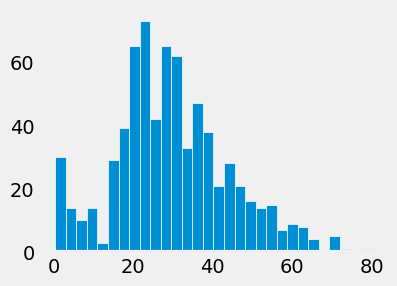

In [9]:
titanic['age'].hist(figsize=(4, 3), bins=30, grid=False, edgecolor='white')

To see all the available styles/themes in the environment, use the syntax:


In [10]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

<!-- # Sample DataFrames for demonstration
import numpy as np

# Create sample data for examples
np.random.seed(42)

df1 = pd.DataFrame({
    'A': np.random.randn(100),
    'B': np.random.randn(100),
    'C': np.random.randn(100)
})

# Use positive values to support stacked area plots
df2 = pd.DataFrame({
    'a': np.random.rand(50),
    'b': np.random.rand(50),
    'c': np.random.rand(50)
}) -->

## Overview

Pandas offers a simple, high-level interface for creating plots directly from Series and DataFrame objects. It builds on Matplotlib behind the scenes, allowing you to make quick, readable plots with calls like `df.plot()` or `series.plot()`. You can easily produce line, bar/stacked bar, area, scatter, box, histogram, KDE, hexbin, and pie charts while using your **index** (including datetime) and **column labels**. 

### The `.plot()` Method

`.plot()`, a wrapper around Matplotlib's `plt.plot()`, is the primary top-level plotting method in pandas, which uses the `kind` **keyword argument** to access a variety of plotting methods including:

- `bar` or `barh` for bar plots
- `hist` for histogram
- `box` for boxplot
- `kde’ or `density` for density plots
- `area` for area plots
- `scatter` for scatter plots
- `hexbin` for hexagonal bin plots
- `pie` for pie plots

### The Plotting Methods (**`df.plot.<kind>`**)

Instead of the `kind=` arguments, your can use the plotting methods directly by using the **`df.plot.<kind>`** syntax, which makes it easier to find other plot methods. In the Python shell, you hit the tab key after df.plot., and in Jupyter, you just type til the dot and the menu with the methods will show up.

```bash
(.venv) tcn85✪mstː~/workspace/dsm$ python
Python 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)] on darwin
Type "help", "copyright", "credits" or "license" for more information.
```
```python
>>> import pandas as pd
>>> df = pd.DataFrame()
>>> df.plot.<TAB>
df.plot.area(     df.plot.box(      df.plot.hist(     df.plot.pie(      
df.plot.bar(      df.plot.density(  df.plot.kde(      df.plot.scatter(  
df.plot.barh(     df.plot.hexbin(   df.plot.line(  
```

### Sample Plots

For example, here we have a piece of randomly generated time series data to plot using `.plot()`, which by default gives you a **line plot**. Because the index consists of dates, `.plot()` calls `gcf().autofmt_xdate()` to try to format the x-axis. 

Text(0.5, 1.0, 'Random Walk Simulation')

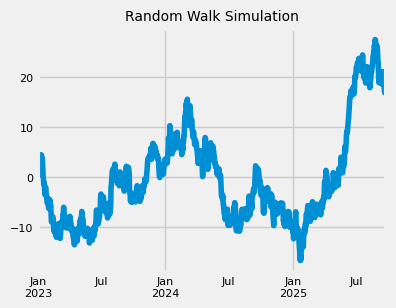

In [11]:
np.random.seed(42)  ### for reproducibility
n = 1000            ### number of time points
ts = pd.Series(np.random.randn(n), index=pd.date_range("2023-01-01", periods=n))
ts = ts.cumsum()    ### cumulative sum to create a random walk

ax = ts.plot(figsize=(4, 3), fontsize=8)  ### plot the entire time series
ax.set_title("Random Walk Simulation", fontsize=10)

For DataFrames, `.plot()` plots all of the columns with labels.

<Figure size 640x480 with 0 Axes>

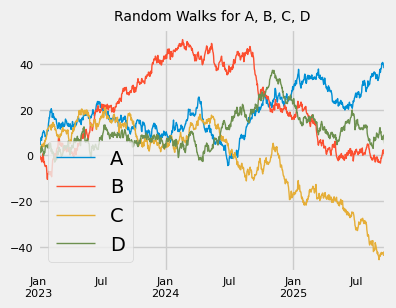

In [12]:
df = pd.DataFrame(np.random.randn(1000, 4), index=ts.index, columns=list("ABCD"))
df = df.cumsum()
plt.figure();
df.plot(figsize=(4, 3), lw=1, fontsize=8);  ### plot all columns together
plt.title("Random Walks for A, B, C, D", fontsize=10);

Or you can pick columns of your choice to plot.

          B         C  A
0 -0.423760 -0.453414  0
1 -2.219403 -0.783504  1
2 -1.486574 -2.057736  2


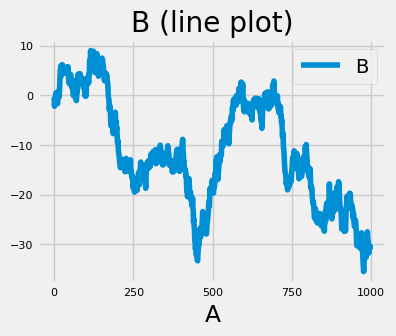

In [13]:
df1 = pd.DataFrame(np.random.randn(1000, 2), columns=["B", "C"]).cumsum()
df1["A"] = pd.Series(list(range(len(df1))))
print(df1.head(3))
df1.plot(x="A", y="B", figsize=(4, 3), fontsize=8, title="B (line plot)");

A histogram can be create with `pd.plot(kind="hist")`. Here we use the **`kind=`** keyword argument to specify the type of plot.

                   A         B         C         D
2023-01-01  1.399355  0.924634  0.059630 -0.646937
2023-01-02  2.097579  1.318119  0.954824 -0.011765
2023-01-03  3.147131  0.782884  2.272218  0.185835
2023-01-04  5.222392  0.093696  4.008181  0.383745
2023-01-05  4.570974 -0.390190  3.687834  0.807911


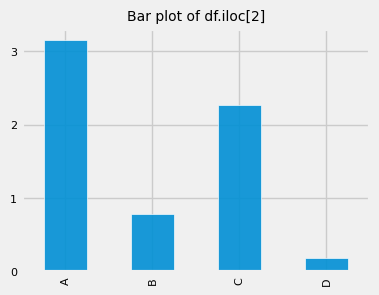

In [14]:
print(df.head())
# plt.figure();
df.iloc[2].plot(kind="bar", figsize=(4, 3), 
        title="Bar plot of df.iloc[2] (using 'kind' argument)", 
        edgecolor="white",
        alpha=0.9,
        fontsize=8);
plt.title("Bar plot of df.iloc[2]", fontsize=10);

We can use the `.plot(kind=)` syntax to generate plots other than the default line plot. For example, a histogram. 

<Axes: title={'center': 'Histogram of ts'}, ylabel='Frequency'>

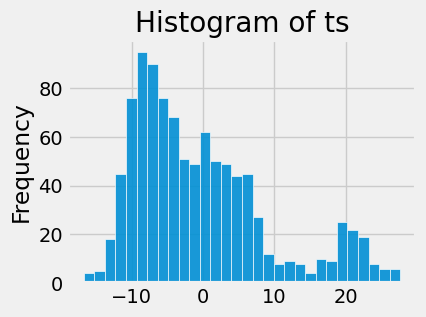

In [15]:
ts.plot(kind="hist", bins=30, figsize=(4, 3),
        title="Histogram of ts",
        edgecolor="white",
        alpha=0.9)

The same plot can be produced using the **`plot.hist()`** method. 

<Axes: title={'center': 'Histogram of ts (using method)'}, ylabel='Frequency'>

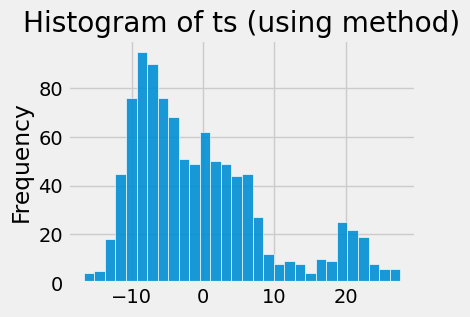

In [16]:
ts.plot.hist(bins=30, figsize=(4, 3),
             title="Histogram of ts (using method)",
             edgecolor="white",
             alpha=0.9)

For example, for histograms:
    1. `df.plot.hist()`: Uses Pandas’ unified `.plot()` interface (which wraps Matplotlib) to draw a histogram.
    2. `df.plot(kind='hist')`: The same as df.plot.hist(); a generic form of the same call.
    3. Pandas has two top-level plotting methods: `df.hist()` (a quick wrapper around Matplotlib’s `plt.hist()` for all numeric columns) and `df.boxplot()`.



| # | Method                 | Applies to          | Subplots              | Overlays Multiple Columns | Based On                 | Typical Use                           |
|:-:|:---------------------- |:------------------- |:--------------------- |:------------------------- |:------------------------ |:------------------------------------- |
| 1 | `df.hist()`            | DataFrame only      | Yes (grid of plots) | No                      | `plt.hist()`             | Quick overview of all numeric columns |
| 2 | `df.plot.hist()`       | DataFrame or Series | Single plot         | Yes                     | Pandas `.plot()` wrapper | Custom, combined histograms           |



2. **Custom parameters**: Most plotting calls accept `Matplotlib` keyword arguments and return a Matplotlib Axes object for further customization. Often used parameters from pandas API reference ([pandas.DataFrame.plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)) include:
   1. `data`: Series or DataFrame. The object for which the method is called.
   2. `x`: label or position, default None. Only used if data is a DataFrame.
   3. `y`: label, position or list of label, positions, default None. Allows plotting of one column versus another. Only used if data is a DataFrame.
   4. `kind`: str. The kind of plot to produce: line (default), bar, barh, hist, box, kde/density, area, pie, scatter (DataFrame only), hexbin (DataFrame only).
   5. `ax`
   6. `figsize` 
   7. `use_index`
   8. `title`
   9. ticks (xticks and yticks): sequence. Values to use for ticks. 
   10. lim (`xlim` and `ylim`): 2-tuple/list. Set the limits of the axes.    
   11. label (`xlabel` and `ylabel`: Name to use for the label on axis (default to index name).
   12. `coloarmap`: str or matplotlib colormap object
   13. `stacked`: bool, default False in line and bar plots, and True in area plot. If True, create stacked plot.
   14. **kwargs ([matplotlib](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html)): 
       1.  `lw` 
       2.  `alpha` 
  

3. **style sheets**: Style the plots to look globally with `plt.style.use(...)`.
  
4. **color & size**: 
    - For scatter plots you can color by a column (`c`) or 
    - size by an array (`s=df['col']*scale`) and 
    - use `cmap` for colormaps.

5. **fine-tuning**: For large or dense data, consider hexbin or KDE plots instead of scatter.

6. **Plot Types**
The `pandas.DataFrame.plot` API lists 11 plots to be used with the `kind` parameter: The kind of plot to produce: `line`(default), `bar`, `barh` (horizontal bar plot), `hist`, `box`, `kde` (`density`), `area`, `pie`, `scatter`, `hexbin`. These plots can be summarized as:


| # | Method | Shorthand | Description | Best For |
|---|--------|-----------|-------------|----------|
| 1 | `.plot(kind='line')` | `.plot.line()` | Line plot | Time series, continuous trends |
| 2 | `.plot(kind='bar')` | `.plot.bar()` | Vertical bar chart | Comparing categories side by side |
| 3 | `.plot(kind='barh')` | `.plot.barh()` | Horizontal bar chart | Long category names, rankings |
| 4 | `.plot(kind='hist')` | `.plot.hist()` | Histogram | Distribution of a single variable |
| 5 | `.plot(kind='box')` | `.plot.box()` | Box plot | Spotting outliers, comparing spread |
| 6 | `.plot(kind='kde')` | `.plot.kde()` | KDE curve | Smooth distribution, comparing shapes |
| 7 | `.plot(kind='density')` | `.plot.density()` | Alias for kde | Same as KDE |
| 8 | `.plot(kind='area')` | `.plot.area()` | Area plot | Cumulative totals, part-to-whole over time |
| 9 | `.plot(kind='pie')` | `.plot.pie()` | Pie chart | Proportions of a whole (few categories) |
| 10 | `.plot(kind='scatter', x='col1', y='col2')` | `.plot.scatter(x='col1', y='col2')` | Scatter plot | Correlation between two numeric variables |
| 11 | `.plot(kind='hexbin', x='col1', y='col2')` | `.plot.hexbin(x='col1', y='col2')` | Hexbin plot | Large datasets, 2D density visualization |

**Notes:**
- `kde` and `density` are aliases — same plot, counted once for unique types
- `scatter` and `hexbin` **require** `x` and `y` arguments
- `pie` requires a single column (`y=` or per-column)
- `scatter` and `hexbin` are **DataFrame only**

<!-- Tips:
- Use the returned Axes for annotation, legends, and fine control (ax.set_title, ax.set_xlabel, etc.).
- Combine pandas plotting with Matplotlib calls for publication-quality figures.
- When plotting many subplots, consider subplots=True and sharex/sharey for consistent axes. -->

Note: Jupyter Notebooks enable inline plotting (no pop-up) with `%matplotlib inline`, which is an IPython magic command that tells Jupyter Notebook to render Matplotlib plots directly inside the notebook output cell instead of in a separate window. You don’t need %matplotlib inline in Jupyter environment with IPython >= 7.

Later, when you learn Matplotlib, you will see why these methods of plotting are a lot easier to use. Pandas visualization balances ease of use with control over the figure. A lot of the plot calls also accept additional arguments of their parent matplotlib.plt call. 



## Section Practice

Use this short exercise to check the main workflow from this section.


In [17]:
### Exercise: Plan a Pandas Plotting Basics Chart
# A team wants to compare sales across four regions.
# Create two lists named regions and sales. Then print the region with the highest sales.
### Your code starts here




### Your code ends here


In [18]:
### Solution
regions = ["North", "South", "East", "West"]
sales = [240, 215, 260, 230]
best_index = sales.index(max(sales))
print(regions[best_index])


East
